In [1]:
from __future__ import annotations

from collections.abc import Iterator, Sequence
import functools
import itertools
from pathlib import Path
from typing_extensions import assert_never

import pandas as pd

from sta.benchmarks.plot_utils import *

In [2]:
ROOT_DIR = Path('../')
OUTPUT_DIR = ROOT_DIR / 'data' / 'segmentation_element'

In [3]:
def get_csv_path(run: RunCombination):
    def percent_digits(x: float):
        return str(x)[2:4].ljust(2, '0')

    base_dir = Path(str(OUTPUT_DIR) + "_" + str(run.num_points) + "_multi_user")
    if not base_dir.exists():
        msg = f"Cannot find base directory {base_dir}"
        raise ValueError(msg)

    run_dir = base_dir / f'perf_label_queries_{run.num_commits}_b_{percent_digits(run.branch_prob)}_c_{percent_digits(run.create_prob)}_d_{percent_digits(run.delete_prob)}_i_{run.num_init_labels}_seed_{run.seed}_iter_{run.iteration}_users_{run.num_users}'
    return run_dir / 'history.csv'

def get_run_data(run: RunCombination):
    path = get_csv_path(run)
    df = pd.read_csv(path)
    df["num_init_labels"] = run.num_init_labels
    df["num_points"] = run.num_points
    df["delete_prob"] = run.delete_prob
    df["num_users"] = run.num_users
    return df

def iter_runs(
    num_commits: int = 4000,
    all_num_points: Sequence[int] = (500,),
    all_create_probs: Sequence[float] = (0.35,),
    all_delete_probs: Sequence[float] = (0.10,),
    all_num_init_labels: Sequence[int] = (0,),
    all_seeds: Sequence[int] = (1, 2, 3),
    all_iters: Sequence[int] = (1, 2, 3),
    all_num_users: Sequence[int] = (1, 4, 8, 16),
):
    for num_points in all_num_points:
        for num_init_labels in all_num_init_labels:
            for create_prob in all_create_probs:
                for delete_prob in all_delete_probs:
                    for seed in all_seeds:
                        for iteration in all_iters:
                            for num_users in all_num_users:
                                yield RunCombination(
                                    num_commits=num_commits,
                                    num_init_labels=num_init_labels,
                                    num_points=num_points,
                                    branch_prob=0.00,
                                    create_prob=create_prob,
                                    delete_prob=delete_prob,
                                    entity_prob=0.20,
                                    seed=seed,
                                    iteration=iteration,
                                    num_users=num_users,
                                )

def get_plot_data(runs: Iterator[RunCombination]):
    runs_lst = list(runs)
    plot_df = pd.concat(get_run_data(run) for run in runs_lst if get_csv_path(run).exists())
    bin_params = max(runs_lst, key=lambda r: (r.create_prob - r.delete_prob)).get_params()

    return plot_df, bin_params

In [4]:
def get_title_for_combination(params: ParametersCombination):
    return r'$\mathbf{' + f'N_i = {params.num_init_labels}; N_c = {params.num_commits}; N_p = {params.num_points}; P_c = {params.create_prob}; P_d = {params.delete_prob}' + r'}$'

In [5]:
def get_query_verb(query_type: QueryType):
    if query_type == 'select':
        return 'Select'
    if query_type == 'create':
        return 'Insert'
    if query_type == 'update':
        return 'Update'
    if query_type == 'delete':
        return 'Delete'

    assert_never(query_type)

def get_label_noun(label_type: LabelType):
    if label_type == 'entity':
        return 'Entity'
    if label_type == 'element':
        return 'Element'

    assert_never(label_type)

def get_by_noun(by: str):
    if by == 'num_labels':
        return 'Data Size'
    if by == 'num_commits':
        return 'Graph Size'

    raise NotImplementedError

def get_row_plot_fns_for_query_summary(query_type: QueryType, runs: Iterator[RunCombination], vary: str, by_all: tuple[str, ...] = ('num_labels', 'num_commits'), fit: bool = False, fit_ignore_x_col_range: tuple[int, int] | None = None):
    verb = get_query_verb(query_type)
    plot_df, bin_params = get_plot_data(runs)

    return {
        f'{verb} Cost vs {get_by_noun(by)}': functools.partial(
            plot_query_cost_summary_partial,
            plot_df,
            query_type=query_type,
            label_type=label_type,
            by=by,
            vary=vary,
            bin_params=bin_params,
            fit=fit,
            fit_ignore_x_col_range=fit_ignore_x_col_range,
        )
        for label_type in ('element',)  # ('entity', 'element')
        for by in by_all
    }

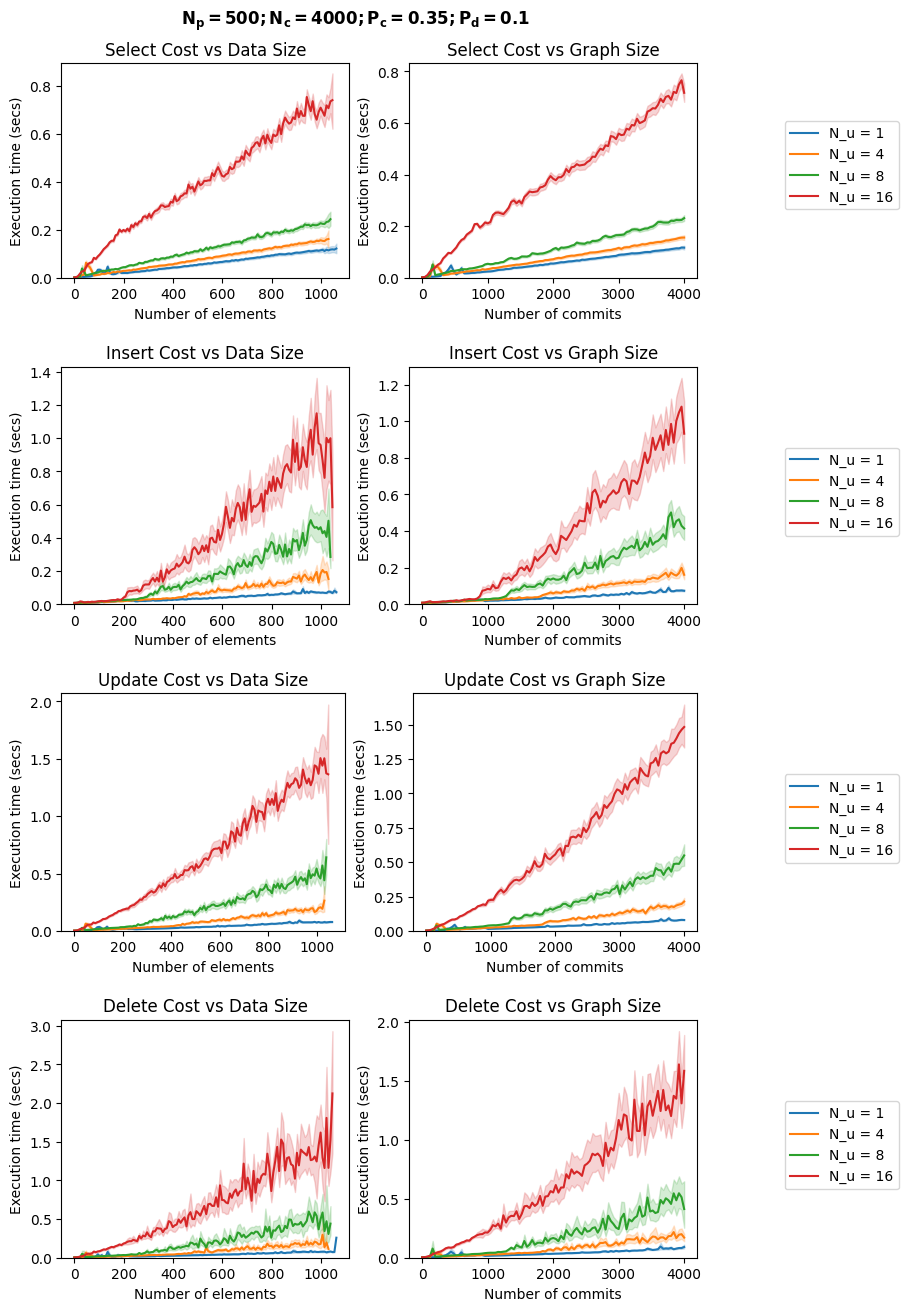

In [6]:
def get_title_for_group_by_num_users(params: ParametersCombination):
    return r'$\mathbf{' + f'N_p = {params.num_points}; N_c = {params.num_commits}; P_c = {params.create_prob}; P_d = {params.delete_prob}' + r'}$'


def get_rows_for_query_summary_by_num_users(params: ParametersCombination, runs: Iterator[RunCombination], by_all: tuple[str, ...] = ('num_labels', 'num_commits'), fit: bool = False, fit_ignore_x_col_range: dict[QueryType, tuple[int, int] | None] | None = None):
    runs_ = list(runs)
    fit_ignore_x_col_range = fit_ignore_x_col_range or {}
    vary = "num_users"

    return [
        (get_title_for_group_by_num_users(params), get_row_plot_fns_for_query_summary('select', iter(runs_), vary, by_all=by_all, fit=fit, fit_ignore_x_col_range=fit_ignore_x_col_range.get('select'))),
        ("", get_row_plot_fns_for_query_summary('create', iter(runs_), vary, by_all=by_all, fit=fit, fit_ignore_x_col_range=fit_ignore_x_col_range.get('create'))),
        ("", get_row_plot_fns_for_query_summary('update', iter(runs_), vary, by_all=by_all, fit=fit, fit_ignore_x_col_range=fit_ignore_x_col_range.get('update'))),
        ("", get_row_plot_fns_for_query_summary('delete', iter(runs_), vary, by_all=by_all, fit=fit, fit_ignore_x_col_range=fit_ignore_x_col_range.get('delete'))),
    ]

apply_plot_fns(
    [
        row
        for params, runs in itertools.groupby(iter_runs(), lambda x: x.get_params())
        for row in get_rows_for_query_summary_by_num_users(params, runs)
    ],
    colwidth=3,
    rowheight=3,
    extra_w=1,
    share_legend=True,
).show()

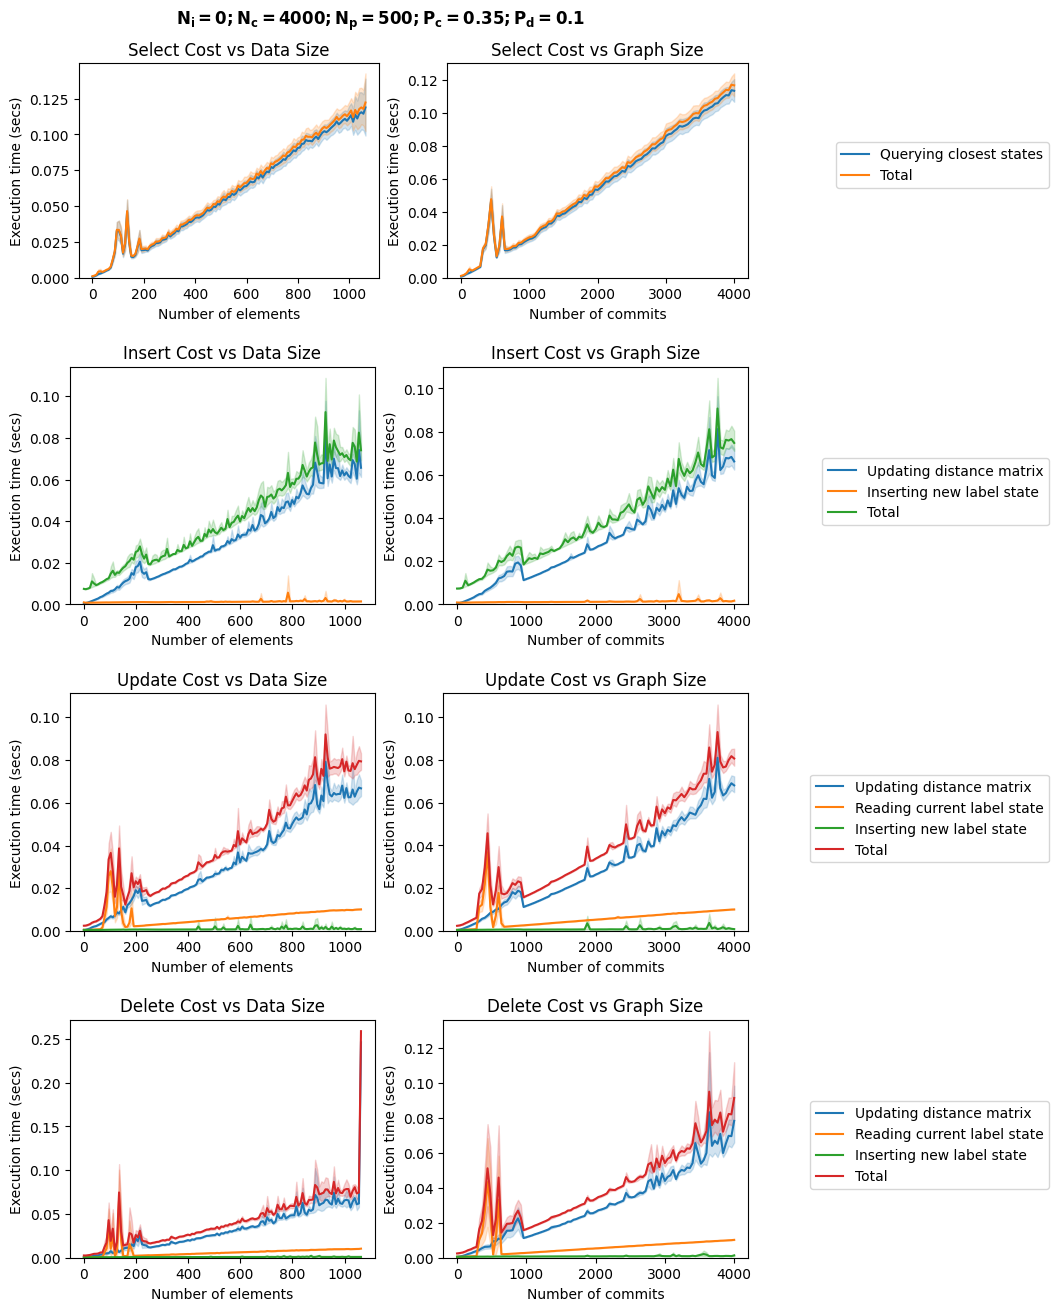

In [7]:
def get_row_plot_fns_for_query_detail(query_type: QueryType, runs: Iterator[RunCombination]):
    verb = get_query_verb(query_type)
    plot_df, bin_params = get_plot_data(runs)

    return {
        f'{verb} Cost vs {get_by_noun(by)}': functools.partial(
            plot_query_cost_detail_partial,
            plot_df,
            query_type=query_type,
            label_type=label_type,
            by=by,
            bin_params=bin_params,
            fit=False,
        )
        for label_type in ('element',)  # ('entity', 'element')
        for by in ('num_labels', 'num_commits')
    }


def get_rows_for_query_detail(params: ParametersCombination, runs: Iterator[RunCombination]):
    runs_ = list(runs)

    return [
        (get_title_for_combination(params), get_row_plot_fns_for_query_detail('select', iter(runs_))),
        ("", get_row_plot_fns_for_query_detail('create', iter(runs_))),
        ("", get_row_plot_fns_for_query_detail('update', iter(runs_))),
        ("", get_row_plot_fns_for_query_detail('delete', iter(runs_))),
    ]

apply_plot_fns(
    [
        row
        for params, runs in itertools.groupby(iter_runs(all_num_users=(1,)), lambda x: x.get_params())
        for row in get_rows_for_query_detail(params, runs)
    ],
    colwidth=3,
    rowheight=3,
    extra_w=1.5,
    share_legend=True,
).show()